# Forecast Intervals with Conformal Prediction

This notebook demonstrates how to add prediction intervals to Hyper-Tree forecasts using conformal prediction. The approach is model-agnostic and works with all Hyper-Tree models (AR, ETS, TreeNet-AR).

**How it works:** During training, a rolling-window cross-validation collects absolute residuals (conformity scores) per horizon step and per series. At forecast time, these scores are used to construct intervals at any requested confidence level.

In [1]:
import pandas as pd
import torch

from hypertrees.models import HyperTreeAR, HyperTreeETS, HyperTreeNetAR
from hypertrees import ForecastIntervals
from utils import plot_model_intervals

## Load and Prepare Data

We use the Air Passengers dataset (monthly, 1949-1960) and reserve the last 12 months for testing.

In [2]:
# The data needs to have the following columns: 'date', 'series_id', 'value'. All other columns are automatically treated as features.
# For the AR-models, you don't have to add lag-values yourself, this happens automatically during training.
df = pd.read_csv('https://datasets-nixtla.s3.amazonaws.com/air-passengers.csv', parse_dates=['ds'])
df.rename(columns={'unique_id': 'series_id', 'ds': 'date', 'y': 'value'}, inplace=True)

# Add month and quarter as features
df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter

# Split into train and test
fcst_h = 12
test = df.tail(fcst_h)
train = df.drop(test.index)

## General Parameters

In [3]:
lag_p = 12
freq = 'MS'
num_iterations = 100
seed = 123
level = [80, 90]
n_windows = 5  # number of rolling calibration windows
refit = False  # train once on the oldest window for speed; True retrains per window
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Conformal prediction intervals, shared by all models
forecast_intervals = ForecastIntervals(
    n_windows=n_windows,
    method="conformal_distribution",    # or "conformal_error"
    step_size=1,
    refit=refit,
)

# LightGBM parameters for all models (can be tuned per model if desired)
ht_params = {
    'learning_rate': 1e-01,
}

# Neural network parameters for Hyper-TreeNet-AR
network_params = {
    'learning_rate': 1e-3,
    'embedding_dimension': 1,
    'hidden_dim': 128,
    'dropout': 0.1,
    'use_random_projection': True,
    'rp_embed_dim': lag_p,
}

## Hyper-Tree-AR with Forecast Intervals

Pass `forecast_intervals=ForecastIntervals(...)` to `train()` to calibrate conformal intervals, then request them via `level=[...]` in `forecast()`.

Key parameters of `ForecastIntervals`:
- **`n_windows`**: Number of rolling CV windows for calibration (more = better quantile resolution, but slower).
- **`method`**: `"conformal_distribution"` (default, can produce asymmetric bands) or `"conformal_error"` (symmetric).
- **`refit`**: If `True` (default), retrain the model for each CV window. If `False`, train once and reuse (faster).

In [4]:
ht_ar = HyperTreeAR(p=lag_p, freq=freq, fcst_h=fcst_h)
ht_ar.train(
    lgb_params=ht_params,
    num_iterations=num_iterations,
    train_data=train,
    seed=seed,
    verbose=-1,
    forecast_intervals=forecast_intervals
)

ht_ar_fcst = ht_ar.forecast(test_data=test, level=level)
ht_ar_fcst.head()

,series_id,date,fcst,model,Hyper-Tree-AR(12)-lo-90,Hyper-Tree-AR(12)-lo-80,Hyper-Tree-AR(12)-hi-80,Hyper-Tree-AR(12)-hi-90
0,AirPassengers,1960-01-01,403.564687,Hyper-Tree-AR(12),377.658879,379.376548,427.752826,429.470495
1,AirPassengers,1960-02-01,402.666936,Hyper-Tree-AR(12),380.005749,385.673160,419.660711,425.328122
2,AirPassengers,1960-03-01,464.129101,Hyper-Tree-AR(12),440.170733,445.990101,482.268101,488.087468
3,AirPassengers,1960-04-01,453.348864,Hyper-Tree-AR(12),436.069989,439.088275,467.609453,470.627739
4,AirPassengers,1960-05-01,466.937535,Hyper-Tree-AR(12),449.502662,453.547709,480.327361,484.372407


## Hyper-Tree-ETS with Forecast Intervals

In [5]:
ht_ets = HyperTreeETS(
    ets_type="triple",
    seasonality_feature="month",
    season_length=12,
    freq=freq,
    fcst_h=fcst_h,
)
ht_ets.train(
    lgb_params=ht_params,
    num_iterations=num_iterations,
    train_data=train,
    seed=seed,
    verbose=-1,
    forecast_intervals=forecast_intervals,
)

ht_ets_fcst = ht_ets.forecast(test_data=test, level=level)
ht_ets_fcst.head()

,series_id,date,fcst,model,Hyper-Tree-ETS(triple)-lo-90,Hyper-Tree-ETS(triple)-lo-80,Hyper-Tree-ETS(triple)-hi-80,Hyper-Tree-ETS(triple)-hi-90
0,AirPassengers,1960-01-01,436.668884,Hyper-Tree-ETS(triple),416.208334,416.849469,456.488300,457.129434
1,AirPassengers,1960-02-01,417.500061,Hyper-Tree-ETS(triple),393.688594,398.844382,436.155740,441.311528
2,AirPassengers,1960-03-01,493.116577,Hyper-Tree-ETS(triple),457.727666,466.906839,519.326315,528.505489
3,AirPassengers,1960-04-01,488.110718,Hyper-Tree-ETS(triple),452.659897,454.806488,521.414948,523.561539
4,AirPassengers,1960-05-01,495.057190,Hyper-Tree-ETS(triple),455.050063,471.988248,518.126132,535.064317


## Hyper-TreeNet-AR with Forecast Intervals

In [6]:
htnet_ar = HyperTreeNetAR(
    p=lag_p,
    freq=freq,
    fcst_h=fcst_h,
    device=device,
)
htnet_ar.train(
    lgb_params=ht_params,
    network_params=network_params,
    num_iterations=num_iterations,
    train_data=train,
    seed=seed,
    verbose=-1,
    forecast_intervals=forecast_intervals,
)

htnet_ar_fcst = htnet_ar.forecast(test_data=test, level=level)
htnet_ar_fcst.head()

,series_id,date,fcst,model,Hyper-TreeNet-AR(12)-lo-90,Hyper-TreeNet-AR(12)-lo-80,Hyper-TreeNet-AR(12)-hi-80,Hyper-TreeNet-AR(12)-hi-90
0,AirPassengers,1960-01-01,412.051285,Hyper-TreeNet-AR(12),388.546278,398.036382,426.066188,435.556292
1,AirPassengers,1960-02-01,408.478998,Hyper-TreeNet-AR(12),380.552001,384.359693,432.598303,436.405995
2,AirPassengers,1960-03-01,434.041320,Hyper-TreeNet-AR(12),404.207984,406.093781,461.988859,463.874656
3,AirPassengers,1960-04-01,441.242457,Hyper-TreeNet-AR(12),414.586314,414.618964,467.865950,467.898600
4,AirPassengers,1960-05-01,458.764859,Hyper-TreeNet-AR(12),432.928178,433.363722,484.165996,484.601539


## Plot Forecasts with Intervals

The `plot_model_intervals` helper detects and shades the interval columns present in each forecast DataFrame.

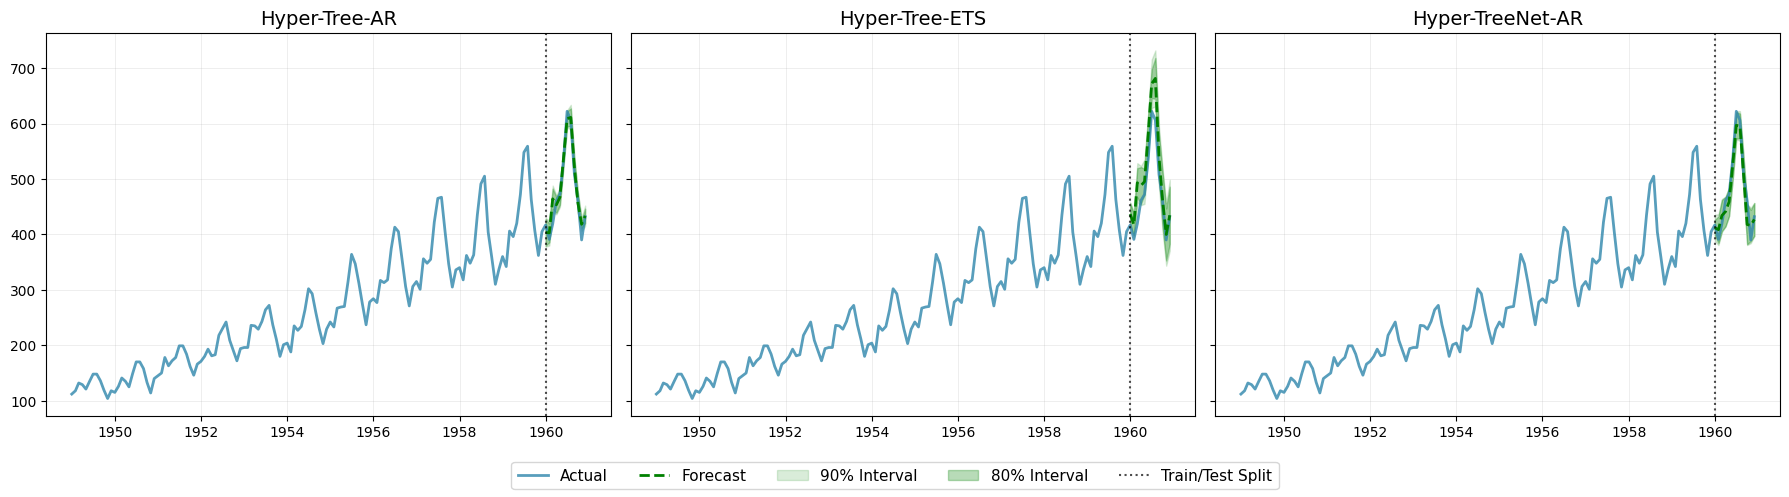

In [7]:
plot_model_intervals(
    actuals=df,
    forecasts={
        "Hyper-Tree-AR": ht_ar_fcst,
        "Hyper-Tree-ETS": ht_ets_fcst,
        "Hyper-TreeNet-AR": htnet_ar_fcst,
    },
)

## Comparing Methods: `conformal_distribution` vs `conformal_error`

The default `conformal_distribution` builds synthetic forecast paths and can produce asymmetric intervals. The alternative `conformal_error` takes quantiles of absolute errors directly, always producing symmetric bands.

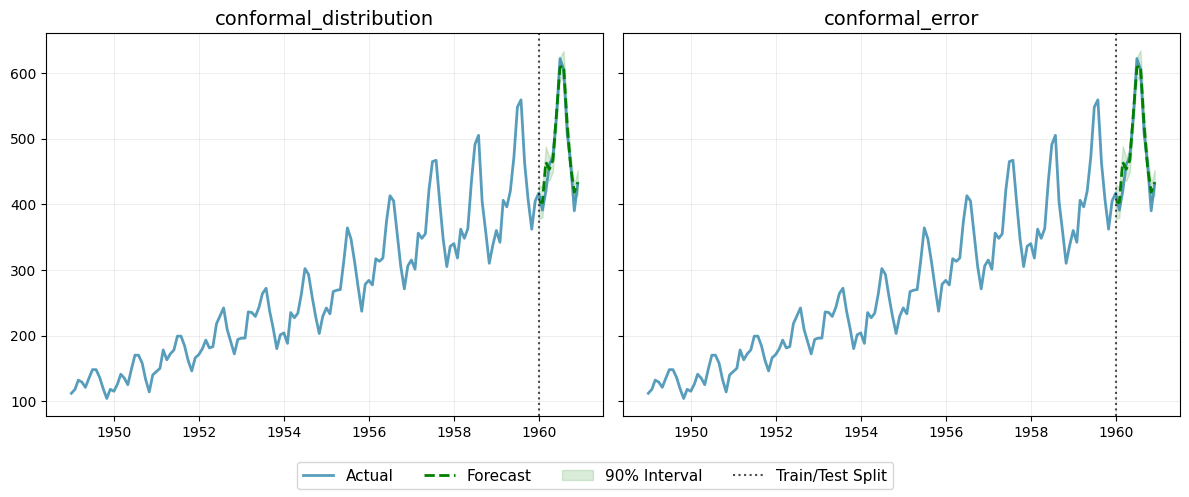

In [8]:
method_fcsts = {}
for method in ["conformal_distribution", "conformal_error"]:
    model = HyperTreeAR(p=lag_p, freq=freq, fcst_h=fcst_h)
    model.train(
        lgb_params=ht_params,
        num_iterations=num_iterations,
        train_data=train,
        seed=seed,
        verbose=-1,
        forecast_intervals=ForecastIntervals(n_windows=n_windows, method=method, step_size=1, refit=refit),
    )
    method_fcsts[method] = model.forecast(test_data=test, level=[90])

plot_model_intervals(actuals=df, forecasts=method_fcsts, levels=[90])